# Lab Assignment 5: Filter Bank Design
### Name: Dewang Choudhary
### Roll No: BL.EN.U4AIE23145
This notebook solves all questions from Assignment 5 with plots and outputs.

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

## Helper Function for Triangular Filter

In [2]:
def triangular_filter(x, a, b, c):
    y = np.zeros_like(x, dtype=float)
    rising = (x >= a) & (x <= b)
    falling = (x >= b) & (x <= c)

    if b != a:
        y[rising] = (x[rising] - a) / (b - a)
    if c != b:
        y[falling] = (c - x[falling]) / (c - b)

    return y

## Task 1(i) Single Triangular Filter (10, 20, 30)

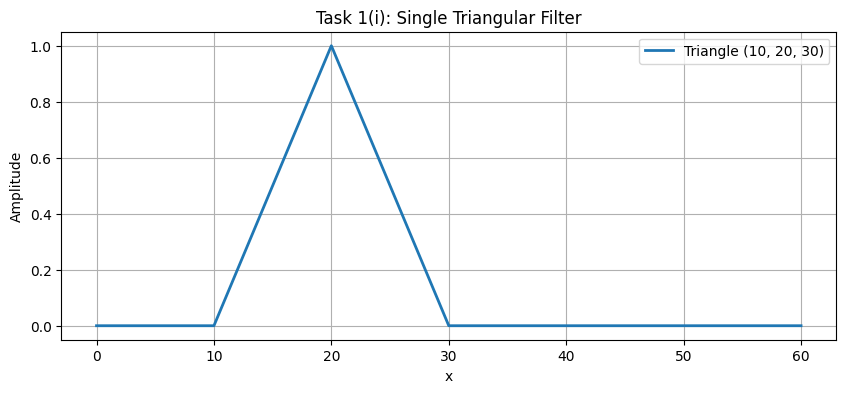

In [3]:
x = np.arange(0, 61)
a, b, c = 10, 20, 30
y = triangular_filter(x, a, b, c)

plt.figure()
plt.plot(x, y, linewidth=2, label=f'Triangle ({a}, {b}, {c})')
plt.title('Task 1(i): Single Triangular Filter')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()

## Task 1(ii) Multiple Triangular Filters

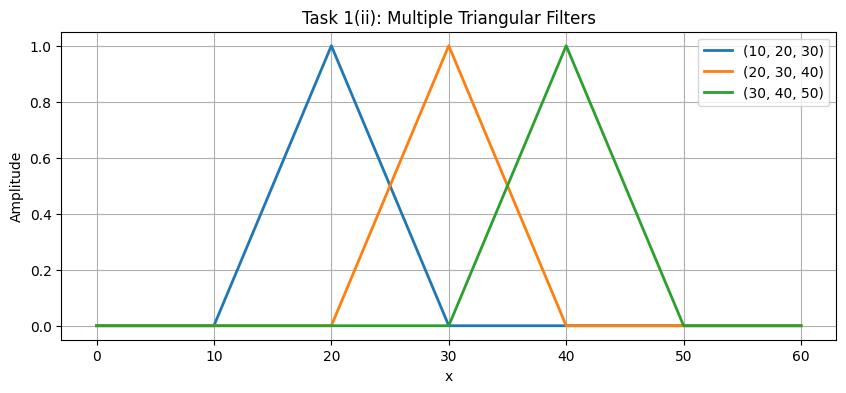

In [4]:
points_list = [(10, 20, 30), (20, 30, 40), (30, 40, 50)]
x = np.arange(0, 61)

plt.figure()
for a, b, c in points_list:
    y = triangular_filter(x, a, b, c)
    plt.plot(x, y, linewidth=2, label=f'({a}, {b}, {c})')

plt.title('Task 1(ii): Multiple Triangular Filters')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()

## Task 1(iii) Wider vs Narrow Triangle

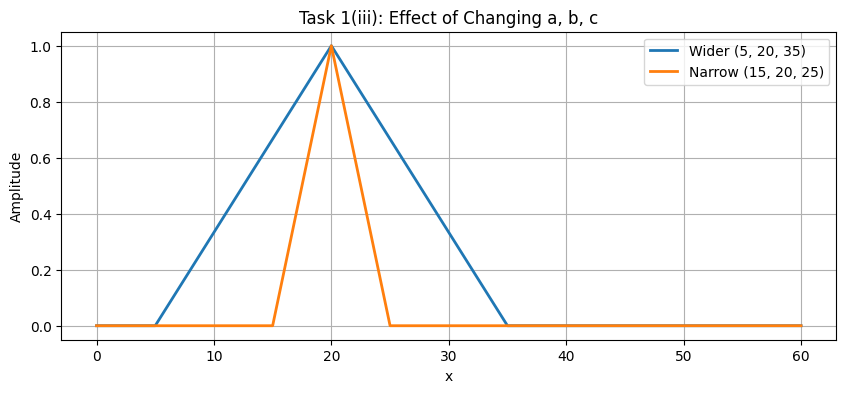

In [5]:
x = np.arange(0, 61)
wider = (5, 20, 35)
narrow = (15, 20, 25)

plt.figure()
plt.plot(x, triangular_filter(x, *wider), linewidth=2, label=f'Wider {wider}')
plt.plot(x, triangular_filter(x, *narrow), linewidth=2, label=f'Narrow {narrow}')
plt.title('Task 1(iii): Effect of Changing a, b, c')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()

## Objective 2 Setup and Mel Conversion Functions

In [6]:
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10**(m / 2595) - 1)

def build_mel_filter_bank(fs=16000, N=512, M=20, fmin=0, fmax=None):
    if fmax is None:
        fmax = fs / 2

    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)

    mel_points = np.linspace(mel_min, mel_max, M + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((N + 1) * hz_points / fs).astype(int)

    filter_bank = np.zeros((M, N // 2 + 1))

    for i in range(1, M + 1):
        a, b, c = bins[i - 1], bins[i], bins[i + 1]

        if b > a:
            filter_bank[i - 1, a:b] = (np.arange(a, b) - a) / (b - a)
        if c > b:
            filter_bank[i - 1, b:c] = (c - np.arange(b, c)) / (c - b)

    return mel_points, hz_points, bins, filter_bank

## Build Mel Filter Bank with Given Parameters

In [7]:
fs = 16000
N = 512
M = 20
fmin = 0
fmax = fs / 2

mel_points, hz_points, bins, mel_fb = build_mel_filter_bank(fs, N, M, fmin, fmax)

print(f'Sampling frequency (fs): {fs} Hz')
print(f'FFT size (N): {N}')
print(f'Number of filters (M): {M}')

Sampling frequency (fs): 16000 Hz
FFT size (N): 512
Number of filters (M): 20


## Report (i) FFT Bin vs Frequency Plot

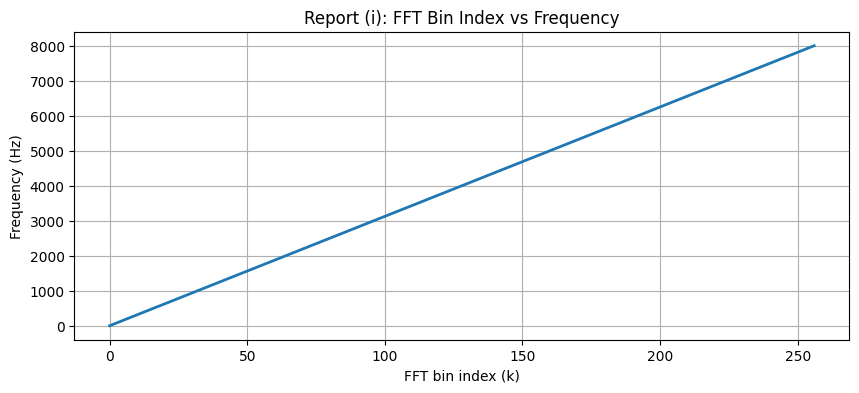

In [8]:
k = np.arange(0, N // 2 + 1)
freqs = k * fs / N

plt.figure()
plt.plot(k, freqs, color='tab:blue', linewidth=2)
plt.title('Report (i): FFT Bin Index vs Frequency')
plt.xlabel('FFT bin index (k)')
plt.ylabel('Frequency (Hz)')
plt.show()

## Report (ii) Mel Points Plot

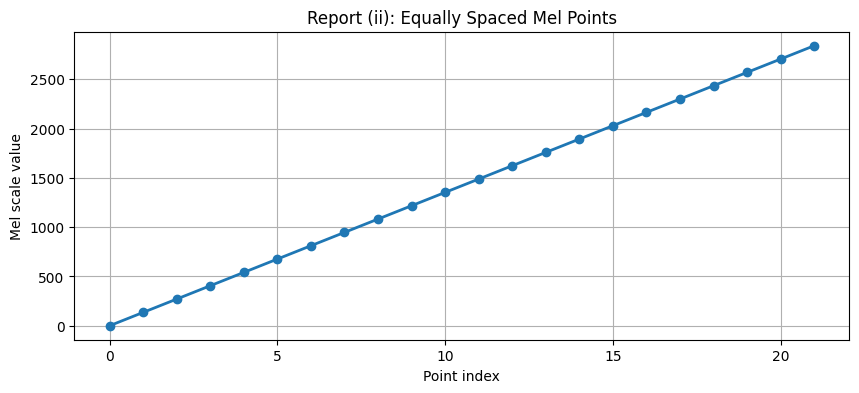

In [9]:
plt.figure()
plt.plot(np.arange(len(mel_points)), mel_points, marker='o', linewidth=2)
plt.title('Report (ii): Equally Spaced Mel Points')
plt.xlabel('Point index')
plt.ylabel('Mel scale value')
plt.show()

## Report (iii) Triangular Filter Points (a, b, c)

In [10]:
print('Filter points in FFT bins and Hz (a, b, c):\n')
for i in range(1, M + 1):
    a_bin, b_bin, c_bin = bins[i - 1], bins[i], bins[i + 1]
    a_hz, b_hz, c_hz = hz_points[i - 1], hz_points[i], hz_points[i + 1]
    print(
        f'Filter {i:02d}: bins=({a_bin:3d}, {b_bin:3d}, {c_bin:3d}) | '
        f'hz=({a_hz:8.2f}, {b_hz:8.2f}, {c_hz:8.2f})'
    )

Filter points in FFT bins and Hz (a, b, c):

Filter 01: bins=(  0,   2,   6) | hz=(    0.00,    89.25,   189.87)
Filter 02: bins=(  2,   6,   9) | hz=(   89.25,   189.87,   303.33)
Filter 03: bins=(  6,   9,  13) | hz=(  189.87,   303.33,   431.25)
Filter 04: bins=(  9,  13,  18) | hz=(  303.33,   431.25,   575.48)
Filter 05: bins=( 13,  18,  23) | hz=(  431.25,   575.48,   738.10)
Filter 06: bins=( 18,  23,  29) | hz=(  575.48,   738.10,   921.46)
Filter 07: bins=( 23,  29,  36) | hz=(  738.10,   921.46,  1128.19)
Filter 08: bins=( 29,  36,  43) | hz=(  921.46,  1128.19,  1361.27)
Filter 09: bins=( 36,  43,  52) | hz=( 1128.19,  1361.27,  1624.08)
Filter 10: bins=( 43,  52,  61) | hz=( 1361.27,  1624.08,  1920.39)
Filter 11: bins=( 52,  61,  72) | hz=( 1624.08,  1920.39,  2254.48)
Filter 12: bins=( 61,  72,  84) | hz=( 1920.39,  2254.48,  2631.17)
Filter 13: bins=( 72,  84,  97) | hz=( 2254.48,  2631.17,  3055.88)
Filter 14: bins=( 84,  97, 113) | hz=( 2631.17,  3055.88,  3534.75)
Fil

## Report (iv) Mel Filter Bank Plot

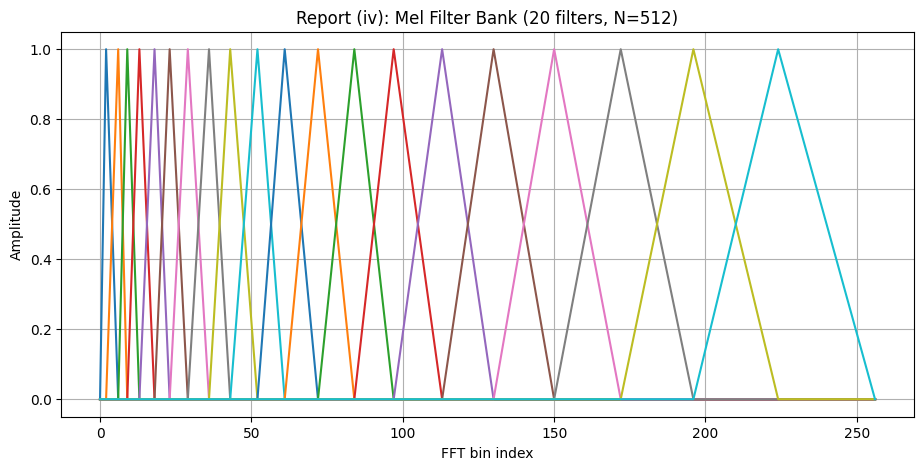

In [11]:
plt.figure(figsize=(11, 5))
for i in range(M):
    plt.plot(mel_fb[i], linewidth=1.5)

plt.title('Report (iv): Mel Filter Bank (20 filters, N=512)')
plt.xlabel('FFT bin index')
plt.ylabel('Amplitude')
plt.ylim(-0.05, 1.05)
plt.show()

## Report (v) Change Parameters and Visualize

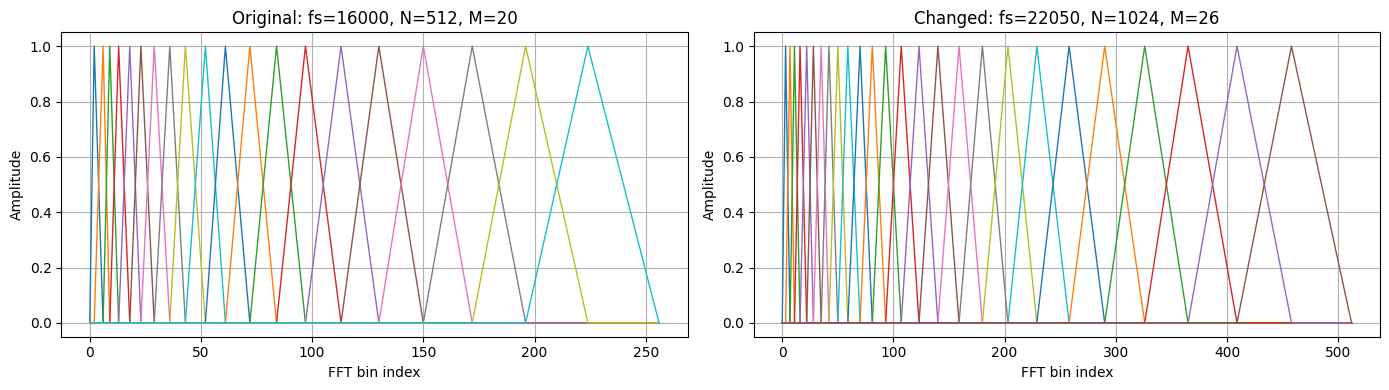

In [12]:
new_fs = 22050
new_N = 1024
new_M = 26

_, _, _, mel_fb_new = build_mel_filter_bank(new_fs, new_N, new_M, 0, new_fs / 2)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

for i in range(M):
    ax[0].plot(mel_fb[i], linewidth=1)
ax[0].set_title(f'Original: fs={fs}, N={N}, M={M}')
ax[0].set_xlabel('FFT bin index')
ax[0].set_ylabel('Amplitude')
ax[0].set_ylim(-0.05, 1.05)
ax[0].grid(True)

for i in range(new_M):
    ax[1].plot(mel_fb_new[i], linewidth=1)
ax[1].set_title(f'Changed: fs={new_fs}, N={new_N}, M={new_M}')
ax[1].set_xlabel('FFT bin index')
ax[1].set_ylabel('Amplitude')
ax[1].set_ylim(-0.05, 1.05)
ax[1].grid(True)

plt.tight_layout()
plt.show()